<a href="https://colab.research.google.com/github/jaykumargaikwad9075-dot/Machine-Learning/blob/main/Assignment_No_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Libraries imported')

Libraries imported


In [2]:
data = {
    'StudyHours':['Low','Medium','High','Low','High','Medium','Low','High','Medium','Low','High','Medium','Low','High'],
    'Attendance':['Poor','Good','Good','Average','Good','Average','Poor','Good','Average','Poor','Good','Average','Poor','Good'],
    'Assignment':['No','Yes','Yes','No','Yes','Yes','No','Yes','Yes','No','Yes','Yes','No','Yes'],
    'Sleep':['Less','Normal','Good','Less','Good','Normal','Less','Good','Normal','Less','Good','Normal','Less','Good'],
    'Result':['Fail','Pass','Pass','Fail','Pass','Pass','Fail','Pass','Pass','Fail','Pass','Pass','Fail','Pass']
}

df = pd.DataFrame(data)
df.to_csv('student_result.csv', index=False)
df


,StudyHours,Attendance,Assignment,Sleep,Result
0,Low,Poor,No,Less,Fail
1,Medium,Good,Yes,Normal,Pass
2,High,Good,Yes,Good,Pass
3,Low,Average,No,Less,Fail
4,High,Good,Yes,Good,Pass
5,Medium,Average,Yes,Normal,Pass
6,Low,Poor,No,Less,Fail
7,High,Good,Yes,Good,Pass
8,Medium,Average,Yes,Normal,Pass
9,Low,Poor,No,Less,Fail


In [3]:
import pandas as pd

# Load dataset
dataset = pd.read_csv('student_result.csv')

# Display first 10 rows
dataset.head(10)


,StudyHours,Attendance,Assignment,Sleep,Result
0,Low,Poor,No,Less,Fail
1,Medium,Good,Yes,Normal,Pass
2,High,Good,Yes,Good,Pass
3,Low,Average,No,Less,Fail
4,High,Good,Yes,Good,Pass
5,Medium,Average,Yes,Normal,Pass
6,Low,Poor,No,Less,Fail
7,High,Good,Yes,Good,Pass
8,Medium,Average,Yes,Normal,Pass
9,Low,Poor,No,Less,Fail


In [4]:
print('Shape:', dataset.shape)
print('\nColumns:', dataset.columns.tolist())

print('\nClass Distribution:')
print(dataset['Result'].value_counts())


Shape: (14, 5)

Columns: ['StudyHours', 'Attendance', 'Assignment', 'Sleep', 'Result']

Class Distribution:
Result
Pass    9
Fail    5
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

# Dictionary to store encoders
encoders = {}

# Copy original dataset
encoded_df = dataset.copy()

# Apply Label Encoding to each column
for col in encoded_df.columns:
    encoders[col] = LabelEncoder()
    encoded_df[col] = encoders[col].fit_transform(encoded_df[col])

# View encoded data
encoded_df.head()


,StudyHours,Attendance,Assignment,Sleep,Result
0,1,2,0,1,0
1,2,1,1,2,1
2,0,1,1,0,1
3,1,0,0,1,0
4,0,1,1,0,1


In [6]:
# Separate features and target
X = encoded_df.drop('Result', axis=1)
y = encoded_df['Result']

# View first few rows of features
X.head()


,StudyHours,Attendance,Assignment,Sleep
0,1,2,0,1
1,2,1,1,2
2,0,1,1,0
3,1,0,0,1
4,0,1,1,0


In [7]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

# Display sizes
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)


Training size: (9, 4)
Testing size: (5, 4)


In [8]:
from sklearn.tree import DecisionTreeClassifier

# Create decision tree model using entropy (ID3)
dt = DecisionTreeClassifier(criterion='entropy', random_state=1)

# Train the model
dt.fit(X_train, y_train)

print('Decision Tree model trained')


Decision Tree model trained


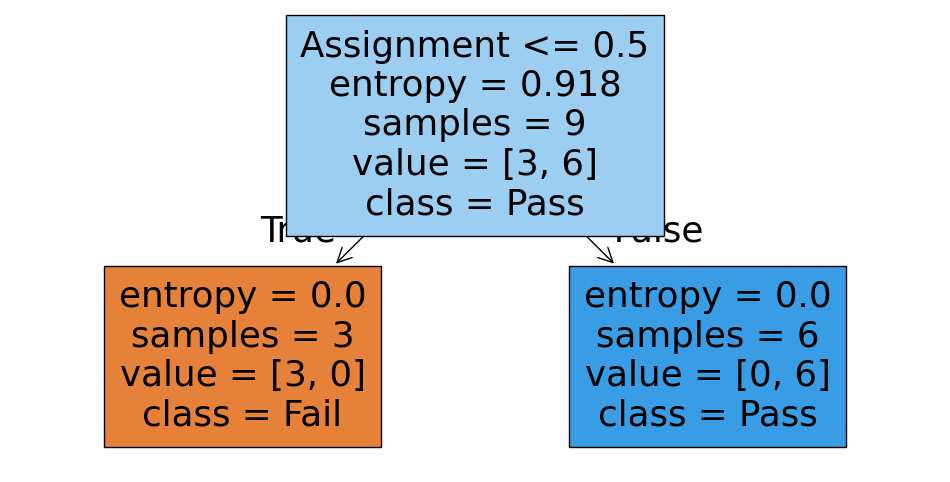

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the decision tree
plt.figure(figsize=(12,6))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['Fail','Pass'],
    filled=True
)

plt.show()


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Make predictions on test data
y_pred = dt.predict(X_test)

# Create comparison table
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Check correctness
results['Status'] = results.apply(
    lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong',
    axis=1
)

print(results)

# Accuracy
print('\nAccuracy:', accuracy_score(y_test, y_pred))

# Confusion Matrix
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))

# Classification Report
print('\nClassification Report:\n', classification_report(y_test, y_pred))


   Actual  Predicted   Status
0       0          0  Correct
1       1          1  Correct
2       0          0  Correct
3       1          1  Correct
4       1          1  Correct

Accuracy: 1.0

Confusion Matrix:
 [[2 0]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

